In [43]:
# imports and plotting defaults
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from long_term_wear_plotting import (
    mask_to_segments,
    merge_close_segments,
    drop_tiny_segments,
    plot_group,
    plot_all_signals_one_figure,
    keep_min_duration_segments,
    add_wrist_flex_ext_from_imus,
)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = False

In [44]:
# fixed display settings
adc_ylim_map = {
    "ADC_ch0": (1.24, 1.34),  # Index
    "ADC_ch1": (1.30, 1.40),  # Thumb
    # "ADC_ch0": (1.2, 1.5),  # Index
    # "ADC_ch1": (1.2, 1.5),  # Thumb

}

label_colors = {
    "walking": "#5B8FF9", #blue
    "typing": "#61DDAA", #green
    "eating": "#F6BD16", #yellow-orange
    "texting": "#F08BB4", #pink
    "resting": "#9270CA", #purple
    "bluetooth down": "#7F7F7F", #gray
    "sensor disconnected": "#D62728", #red
    "IMU2 disconnected": "#D62728", #red
    "pressure": "#5B8FF9", #blue
    "bending": "#F6BD16", #yellow-orange

}

display_name_map = {
    "ADC_ch0": "Index MCP (raw ADC)",
    "ADC_ch1": "Thumb MP (raw ADC)",
    "IMU1_H": "Wrist IMU H",
    "IMU1_P": "Wrist IMU P",
    "IMU1_R": "Wrist IMU R",
    "IMU1_W": "Wrist IMU W",
    "IMU1_X": "Wrist IMU X",
    "IMU1_Y": "Wrist IMU Y",
    "IMU1_Z": "Wrist IMU Z",
    "IMU2_H": "HB IMU H",
    "IMU2_P": "HB IMU P",
    "IMU2_R": "HB IMU R",
    "IMU2_W": "HB IMU W",
    "IMU2_X": "HB IMU X",
    "IMU2_Y": "HB IMU Y",
    "IMU2_Z": "HB IMU Z",
}

group_title_map = {
    "IMU1 Euler": "Wrist IMU Euler",
    "IMU2 Euler": "HB IMU Euler",
    "IMU1 Quaternion": "Wrist IMU Quaternion",
    "IMU2 Quaternion": "HB IMU Quaternion",
    "ADC": "Strain Sensors",
}

In [45]:
# choose session
session_date = "2026_03_05"
file_pattern = "6hr_kinwatch_unified_*.csv"
#file_pattern = "*_kinwatch_unified_*.csv" 

In [46]:
#loading file

# make Code/analysis importable so we can use the shared config.py
analysis_dir = Path.cwd().resolve().parent
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from config import path_to_repository

repo_dir = Path(path_to_repository).resolve()
data_root = repo_dir / "CSV Data" / "long_term_wear_data"

data_dir = data_root / session_date
csv_files = sorted(data_dir.glob(file_pattern))
if not csv_files:
    raise FileNotFoundError(f"No files matching {file_pattern} found in {data_dir}")

csv_path = csv_files[-1]
print("Using file:", csv_path)

df = pd.read_csv(csv_path)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

t0 = df["Timestamp"].iloc[0]
df["elapsed_sec"] = (df["Timestamp"] - t0).dt.total_seconds()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["elapsed_hr"]  = df["elapsed_sec"] / 3600

# derive wrist flexion/extension from the two IMUs
df = add_wrist_flex_ext_from_imus(
    df,
    quat_order="wxyz",
    fixed_axis="y",
    moving_axis="y",
    plane_normal_axis="z",
    out_col="wrist_flex_ext_deg",
    zero_baseline=True,
    baseline_window_sec=10.0,
    baseline_stat="median",
    abs_value=False,   # starting with signed trace
    sign=1.0,          # change to -1.0 if the direction is flipped
)

print("Start:", df["Timestamp"].iloc[0])
print("End:  ", df["Timestamp"].iloc[-1])
print(f"Duration: {df['elapsed_hr'].iloc[-1]:.2f} hr")
print("Shape:", df.shape)

Using file: /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/CSV Data/long_term_wear_data/2026_03_05/6hr_kinwatch_unified_20260305_113940.csv


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_5923/2323654229.py:21: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Start: 2026-03-05 19:39:40.244000+00:00
End:   2026-03-06 01:48:40.200000+00:00
Duration: 6.15 hr
Shape: (2972287, 42)


In [47]:
# inspect cols
list(df.columns)

['Timestamp',
 'Counter',
 'IMU1_H',
 'IMU1_P',
 'IMU1_R',
 'IMU1_W',
 'IMU1_X',
 'IMU1_Y',
 'IMU1_Z',
 'IMU1_sys',
 'IMU1_gyro',
 'IMU1_accel',
 'IMU1_mag',
 'IMU2_H',
 'IMU2_P',
 'IMU2_R',
 'IMU2_W',
 'IMU2_X',
 'IMU2_Y',
 'IMU2_Z',
 'IMU2_sys',
 'IMU2_gyro',
 'IMU2_accel',
 'IMU2_mag',
 'ADC_ch0',
 'ADC_ch1',
 'Note',
 'elapsed_sec',
 'elapsed_min',
 'elapsed_hr',
 'euler1_w',
 'euler1_x',
 'euler1_y',
 'euler1_z',
 'euler2_w',
 'euler2_x',
 'euler2_y',
 'euler2_z',
 'imu_bend_deg',
 'imu_pitch_deg',
 'imu_azimuth_deg',
 'wrist_flex_ext_deg']

In [48]:
# printing rows with notes
if "Note" not in df.columns:
    raise ValueError("No 'Note' column found in this file.")

note_mask = df["Note"].fillna("").astype(str).str.strip() != ""
note_rows = df.loc[note_mask, ["Timestamp", "elapsed_min", "elapsed_hr", "Counter", "Note"]].copy()

print(f"Found {len(note_rows)} rows with notes")
note_rows

Found 15 rows with notes


,Timestamp,elapsed_min,elapsed_hr,Counter,Note
14287,2026-03-05 19:41:18.967000+00:00,1.645383,0.027423,1284,texting start
23725,2026-03-05 19:42:24.150000+00:00,2.731767,0.045529,1935,texting stop
40413,2026-03-05 19:44:19.807000+00:00,4.659383,0.077656,3090,disconnected Channel 1 mag connector
194288,2026-03-05 20:02:06.823000+00:00,22.442983,0.374050,13749,walk to lunch start
211548,2026-03-05 20:04:06.188000+00:00,24.432400,0.407207,14941,lunch start
325524,2026-03-05 20:17:13.615000+00:00,37.556183,0.625936,22807,lunch end
327615,2026-03-05 20:17:27.982000+00:00,37.795633,0.629927,22951,walking start
445096,2026-03-05 20:30:59.193000+00:00,51.315817,0.855264,31055,walking end
519222,2026-03-05 20:39:29.896000+00:00,59.827533,0.997126,36155,lecture start
1943045,2026-03-05 23:49:57.928000+00:00,250.294733,4.171579,134582,texting


In [49]:
for _, row in note_rows.iterrows():
    print(f"{row['elapsed_min']:8.3f} min | {row['Timestamp']} | {row['Note']}")

end_min = df["elapsed_min"].iloc[-1]
print("end of recording:", end_min)

   1.645 min | 2026-03-05 19:41:18.967000+00:00 | texting start
   2.732 min | 2026-03-05 19:42:24.150000+00:00 | texting stop
   4.659 min | 2026-03-05 19:44:19.807000+00:00 | disconnected Channel 1 mag connector
  22.443 min | 2026-03-05 20:02:06.823000+00:00 | walk to lunch start
  24.432 min | 2026-03-05 20:04:06.188000+00:00 | lunch start
  37.556 min | 2026-03-05 20:17:13.615000+00:00 | lunch end
  37.796 min | 2026-03-05 20:17:27.982000+00:00 | walking start
  51.316 min | 2026-03-05 20:30:59.193000+00:00 | walking end
  59.828 min | 2026-03-05 20:39:29.896000+00:00 | lecture start
 250.295 min | 2026-03-05 23:49:57.928000+00:00 | texting
 252.249 min | 2026-03-05 23:51:55.182000+00:00 | texting stop
 266.163 min | 2026-03-06 00:05:50.017000+00:00 | walking to bus
 267.949 min | 2026-03-06 00:07:37.169000+00:00 | walking to bus while holding laptop
 297.087 min | 2026-03-06 00:36:45.468000+00:00 | mechanical press before
 297.342 min | 2026-03-06 00:37:00.760000+00:00 | bend bef

In [50]:
# pick cols to plot
plot_groups = {
    "IMU1 Euler": ["IMU1_H", "IMU1_P", "IMU1_R"],
    "IMU1 Quaternion": ["IMU1_W", "IMU1_X", "IMU1_Y", "IMU1_Z"],
    "IMU2 Euler": ["IMU2_H", "IMU2_P", "IMU2_R"],
    "IMU2 Quaternion": ["IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"],
    "ADC": ["ADC_ch0", "ADC_ch1"],
}

plot_groups = {
    k: [c for c in v if c in df.columns]
    for k, v in plot_groups.items()
    if any(c in df.columns for c in v)
}

plot_groups

{'IMU1 Euler': ['IMU1_H', 'IMU1_P', 'IMU1_R'],
 'IMU1 Quaternion': ['IMU1_W', 'IMU1_X', 'IMU1_Y', 'IMU1_Z'],
 'IMU2 Euler': ['IMU2_H', 'IMU2_P', 'IMU2_R'],
 'IMU2 Quaternion': ['IMU2_W', 'IMU2_X', 'IMU2_Y', 'IMU2_Z'],
 'ADC': ['ADC_ch0', 'ADC_ch1']}

In [51]:
# defining activity segments to shade
manual_segments = [
    # 6hr
    {"start_min": 1.645383	, "end_min": 2.731767, "label": "texting"},
    {"start_min": 22.442983	, "end_min": 24.432400, "label": "walking"},
    {"start_min": 24.432400	, "end_min": 37.556183, "label": "eating"},
    {"start_min": 37.795633	, "end_min": 51.315817, "label": "walking"},
    {"start_min": 59.827533	, "end_min": 119.827533, "label": "resting"}, # end not real
    {"start_min": 250.294733, "end_min": 252.248967, "label": "texting"},
    {"start_min": 266.162883, "end_min": 296.162883, "label": "walking"}, # end not real
    {"start_min": 310	, "end_min": end_min, "label": "resting"},

    # # 6hr2
    # {"start_min": 0	, "end_min": 8.444867	, "label": "eating"},
    # {"start_min": 8.444867		, "end_min": 55.995667, "label": "typing"},
    # {"start_min": 55.995667	, "end_min": 60.758667, "label": "walking"},
    # {"start_min": 60.758667	, "end_min": 76.985817, "label": "resting"},
    # {"start_min": 76.985817	, "end_min": 119.780083, "label": "walking"}, 
    # {"start_min": 119.780083, "end_min": end_min, "label": "typing"},
    
    # pressure 
    # {"start_min": 0.502400		, "end_min": 1.235583, "label": "pressure"},
    # {"start_min": 1.235583	, "end_min": end_min, "label": "bending"},

]


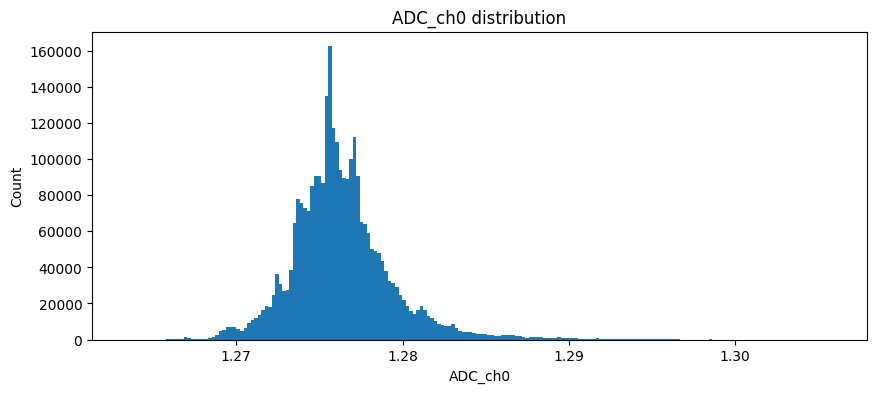

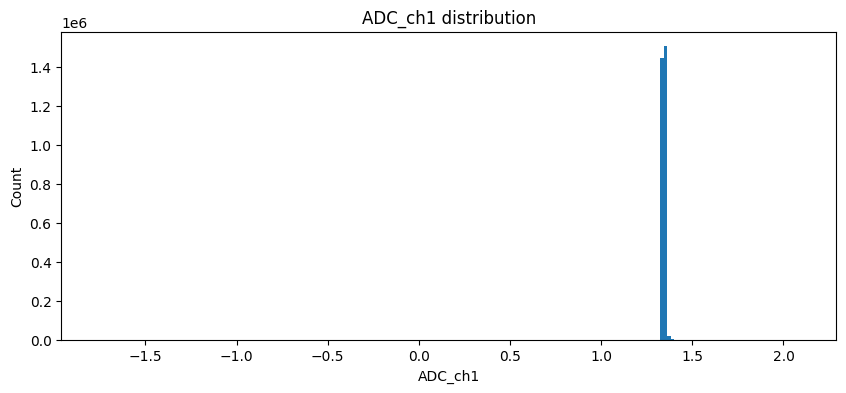

In [52]:
# inspecting ADC disttributions - help decide ylims & threshold
df[["ADC_ch0", "ADC_ch1"]].describe()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch0"].dropna(), bins=200)
plt.title("ADC_ch0 distribution")
plt.xlabel("ADC_ch0")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch1"].dropna(), bins=200)
plt.title("ADC_ch1 distribution")
plt.xlabel("ADC_ch1")
plt.ylabel("Count")
plt.show()

adc_disconnect_threshold = -1
gap_threshold_sec = 1

In [53]:
# detecting ADC disconnect
adc0_disconnected_mask = df["ADC_ch0"] < adc_disconnect_threshold
adc1_disconnected_mask = df["ADC_ch1"] < adc_disconnect_threshold

print("Rows flagged as ADC_ch0 disconnected:", int(adc0_disconnected_mask.sum()))
print("Rows flagged as ADC_ch1 disconnected:", int(adc1_disconnected_mask.sum()))

adc0_disconnect_segments = mask_to_segments(df, adc0_disconnected_mask, "sensor disconnected")
for seg in adc0_disconnect_segments:
    seg["channel"] = "ADC_ch0"

adc1_disconnect_segments = mask_to_segments(df, adc1_disconnected_mask, "sensor disconnected")
for seg in adc1_disconnect_segments:
    seg["channel"] = "ADC_ch1"

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
pd.DataFrame(adc_disconnect_segments).head(20)

Rows flagged as ADC_ch0 disconnected: 0
Rows flagged as ADC_ch1 disconnected: 216


,start_min,end_min,label,channel
0,4.076383,4.076467,sensor disconnected,ADC_ch1
1,4.077750,4.079633,sensor disconnected,ADC_ch1
2,4.081000,4.081000,sensor disconnected,ADC_ch1
3,265.309883,265.310217,sensor disconnected,ADC_ch1
4,265.311517,265.330183,sensor disconnected,ADC_ch1
5,265.331433,265.331433,sensor disconnected,ADC_ch1


In [54]:
# detecting IMU2 disconnect 
imu2_zero_like = df.loc[
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6),
    ["Timestamp", "elapsed_min", "IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
]

print(f"Rows with IMU2 quaternion all ~0: {len(imu2_zero_like)}")
imu2_zero_like.head(20)


imu2_disconnected_mask = (
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6) &
    (df["IMU2_P"].abs() < 1e-6) &
    (df["IMU2_R"].abs() < 1e-6) &
    ((df["IMU2_H"] - 360).abs() < 1e-6)
)

print("Rows flagged as IMU2 disconnected:", int(imu2_disconnected_mask.sum()))
imu2_disconnect_segments = mask_to_segments(df, imu2_disconnected_mask, "IMU2 disconnected")

imu2_disconnect_segments_df = pd.DataFrame(imu2_disconnect_segments)
imu2_disconnect_segments_df.head(20)

Rows with IMU2 quaternion all ~0: 792
Rows flagged as IMU2 disconnected: 792


,start_min,end_min,label
0,188.596117,188.770850,IMU2 disconnected
1,293.351150,293.406633,IMU2 disconnected


In [55]:
# detecting bluetooth-down
# dt_sec was around 0.002 -- so setting threshold to 0.5s for now
df["dt_sec"] = df["Timestamp"].diff().dt.total_seconds()
print(df["dt_sec"].describe())

gap_rows = df[df["dt_sec"] > gap_threshold_sec].copy()
print(f"Initially found {len(gap_rows)} possible Bluetooth gaps > {gap_threshold_sec} s")

bluetooth_segments = []

for idx in gap_rows.index:
    if idx == 0:
        continue

    prev_imu2_disc = bool(imu2_disconnected_mask.iloc[idx - 1]) if idx - 1 in imu2_disconnected_mask.index else False
    curr_imu2_disc = bool(imu2_disconnected_mask.iloc[idx]) if idx in imu2_disconnected_mask.index else False

    if prev_imu2_disc or curr_imu2_disc:
        continue

    bluetooth_segments.append({
        "start_min": float(df.loc[idx - 1, "elapsed_min"]),
        "end_min": float(df.loc[idx, "elapsed_min"]),
        "label": "bluetooth down",
        "gap_sec": float(df.loc[idx, "dt_sec"]),
        "start_time": df.loc[idx - 1, "Timestamp"],
        "end_time": df.loc[idx, "Timestamp"],
    })

bluetooth_segments_df = pd.DataFrame(bluetooth_segments)
print(f"Bluetooth gaps kept after excluding IMU2-disconnect boundaries: {len(bluetooth_segments)}")
bluetooth_segments_df

count    2.972286e+06
mean     7.448797e-03
std      9.110499e-01
min      0.000000e+00
25%      1.000000e-03
50%      2.000000e-03
75%      2.000000e-03
max      1.570380e+03
Name: dt_sec, dtype: float64
Initially found 1 possible Bluetooth gaps > 1 s
Bluetooth gaps kept after excluding IMU2-disconnect boundaries: 1


,start_min,end_min,label,gap_sec,start_time,end_time
0,122.356917,148.529917,bluetooth down,1570.38,2026-03-05 21:42:01.659000+00:00,2026-03-05 22:08:12.039000+00:00


In [56]:
# clean up auto-detected segments
adc0_disconnect_segments = merge_close_segments(adc0_disconnect_segments, max_gap_min=0.005)
adc1_disconnect_segments = merge_close_segments(adc1_disconnect_segments, max_gap_min=0.005)
imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.005)
bluetooth_segments = merge_close_segments(bluetooth_segments, max_gap_min=0.01)

adc0_disconnect_segments = drop_tiny_segments(adc0_disconnect_segments, min_duration_min=0.002)
adc1_disconnect_segments = drop_tiny_segments(adc1_disconnect_segments, min_duration_min=0.002)
imu2_disconnect_segments = drop_tiny_segments(imu2_disconnect_segments, min_duration_min=0.002)
bluetooth_segments = drop_tiny_segments(bluetooth_segments, min_duration_min=0.002)

imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.05)
imu2_disconnect_segments = keep_min_duration_segments(imu2_disconnect_segments, min_duration_min=0.25)

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments

print("ADC_ch0 cleaned segments:", len(adc0_disconnect_segments))
print("ADC_ch1 cleaned segments:", len(adc1_disconnect_segments))
print("IMU2 cleaned segments:", len(imu2_disconnect_segments))
print("Bluetooth cleaned segments:", len(bluetooth_segments))
print("Combined ADC cleaned segments:", len(adc_disconnect_segments))

ADC_ch0 cleaned segments: 0
ADC_ch1 cleaned segments: 2
IMU2 cleaned segments: 0
Bluetooth cleaned segments: 1
Combined ADC cleaned segments: 2


In [57]:
# replace with NaNs
df_plot = df.copy()

if "ADC_ch0" in df_plot.columns:
    df_plot.loc[adc0_disconnected_mask, "ADC_ch0"] = np.nan

if "ADC_ch1" in df_plot.columns:
    df_plot.loc[adc1_disconnected_mask, "ADC_ch1"] = np.nan

if "wrist_flex_ext_deg" in df_plot.columns:
    df_plot.loc[imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
for col in imu2_cols:
    if col in df_plot.columns:
        df_plot.loc[imu2_disconnected_mask, col] = np.nan

In [58]:
# chronological segment table
all_segments_chron = []

for seg in manual_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "manual"
    })

for seg in bluetooth_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

for seg in adc_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": seg.get("channel", "auto")
    })

for seg in imu2_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

if all_segments_chron:
    all_segments_chron_df = (
        pd.DataFrame(all_segments_chron)
        .sort_values(["start_min", "end_min"])
        .reset_index(drop=True)
    )
else:
    all_segments_chron_df = pd.DataFrame(columns=["start_min", "end_min", "label", "source"])

all_segments_chron_df

,start_min,end_min,label,source
0,1.645383,2.731767,texting,manual
1,4.076383,4.081000,sensor disconnected,ADC_ch1
2,22.442983,24.432400,walking,manual
3,24.432400,37.556183,eating,manual
4,37.795633,51.315817,walking,manual
5,59.827533,119.827533,resting,manual
6,122.356917,148.529917,bluetooth down,auto
7,250.294733,252.248967,texting,manual
8,265.309883,265.331433,sensor disconnected,ADC_ch1
9,266.162883,296.162883,walking,manual


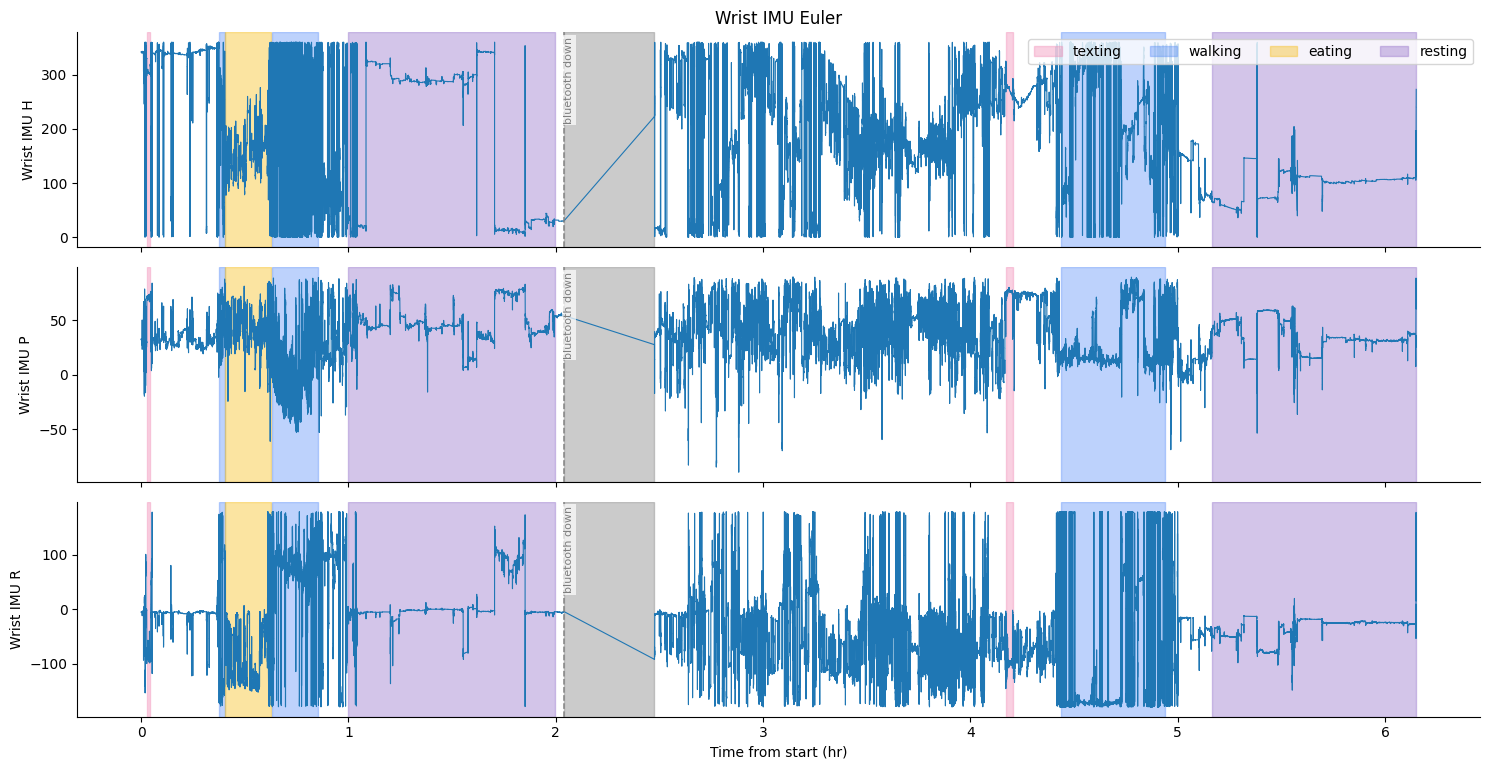

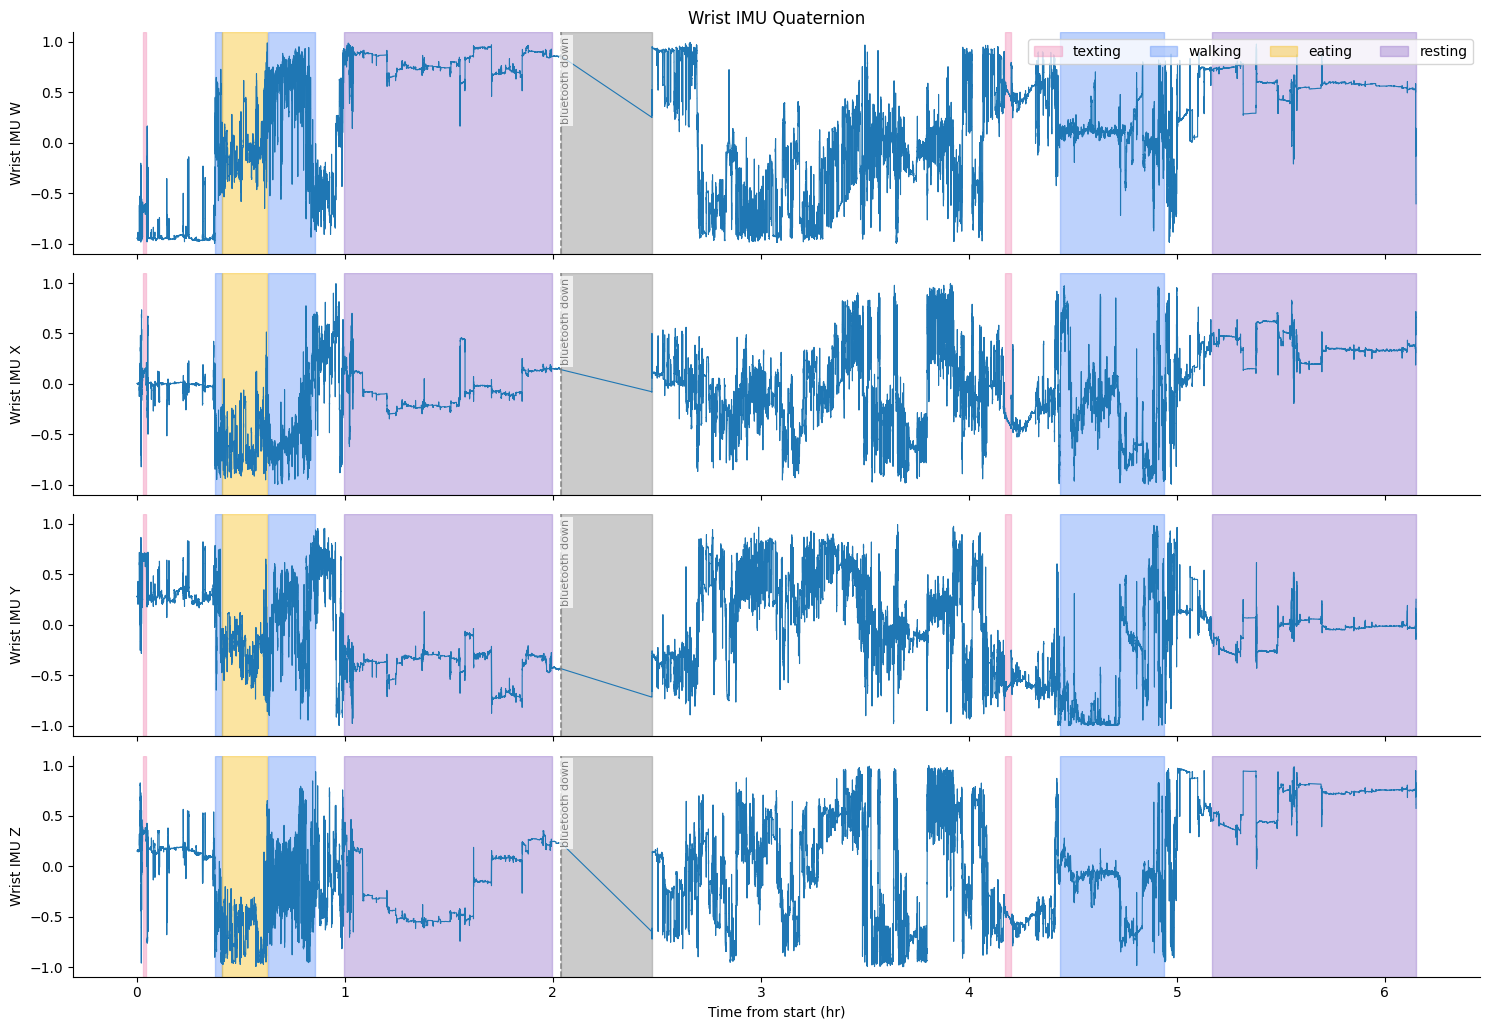

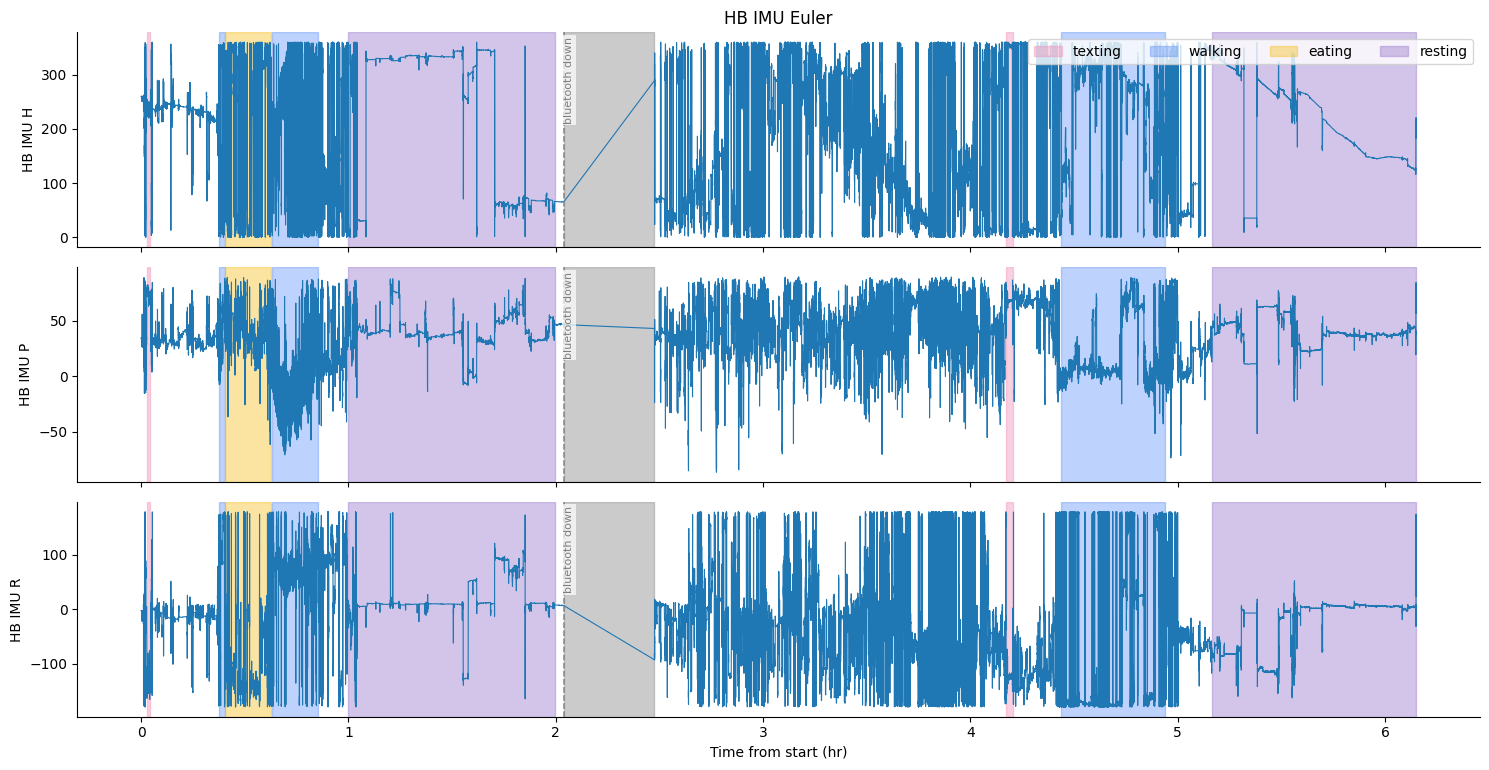

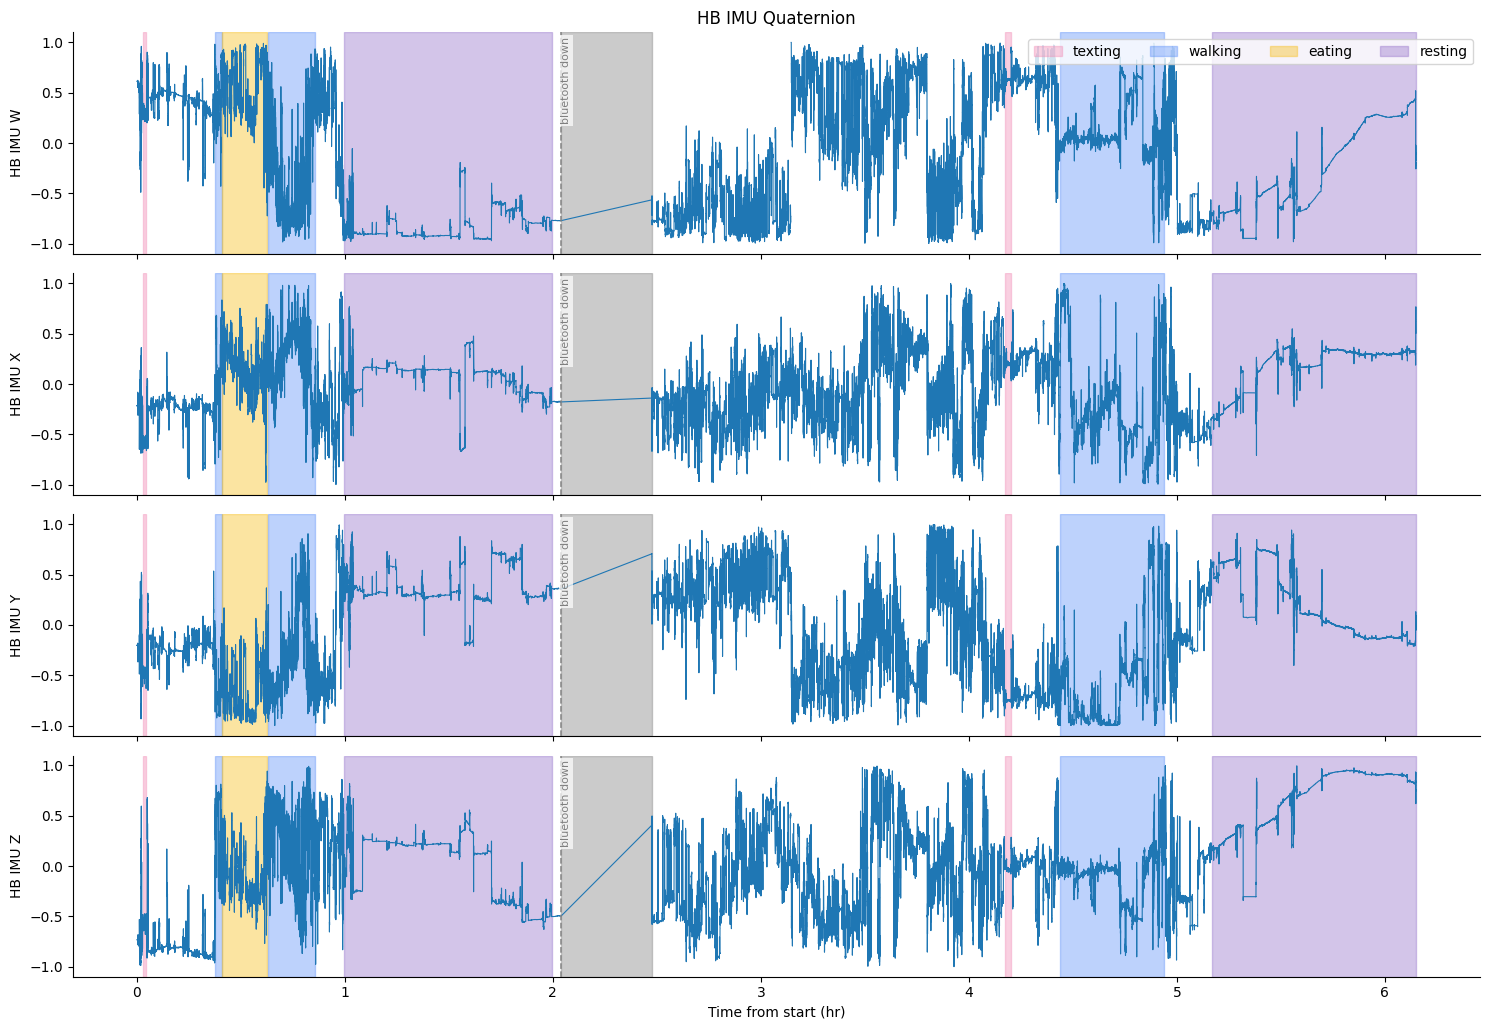

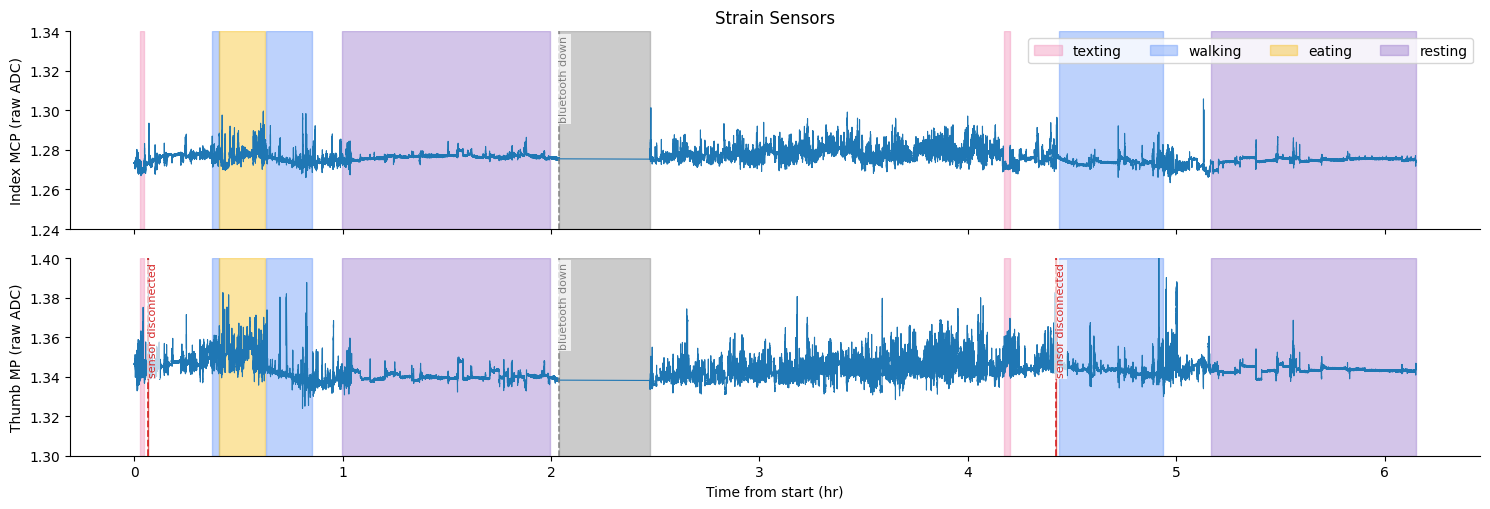

In [59]:
# individual plots
for title, cols in plot_groups.items():
    plot_group(
        df_plot,
        cols,
        title=title,
        manual_segments=manual_segments,
        bluetooth_segments=bluetooth_segments,
        adc_disconnect_segments=adc_disconnect_segments,
        imu2_disconnect_segments=imu2_disconnect_segments,
        label_colors=label_colors,
        display_name_map=display_name_map,
        group_title_map=group_title_map,
        adc_ylim_map=adc_ylim_map,
        xcol="elapsed_hr",
    )

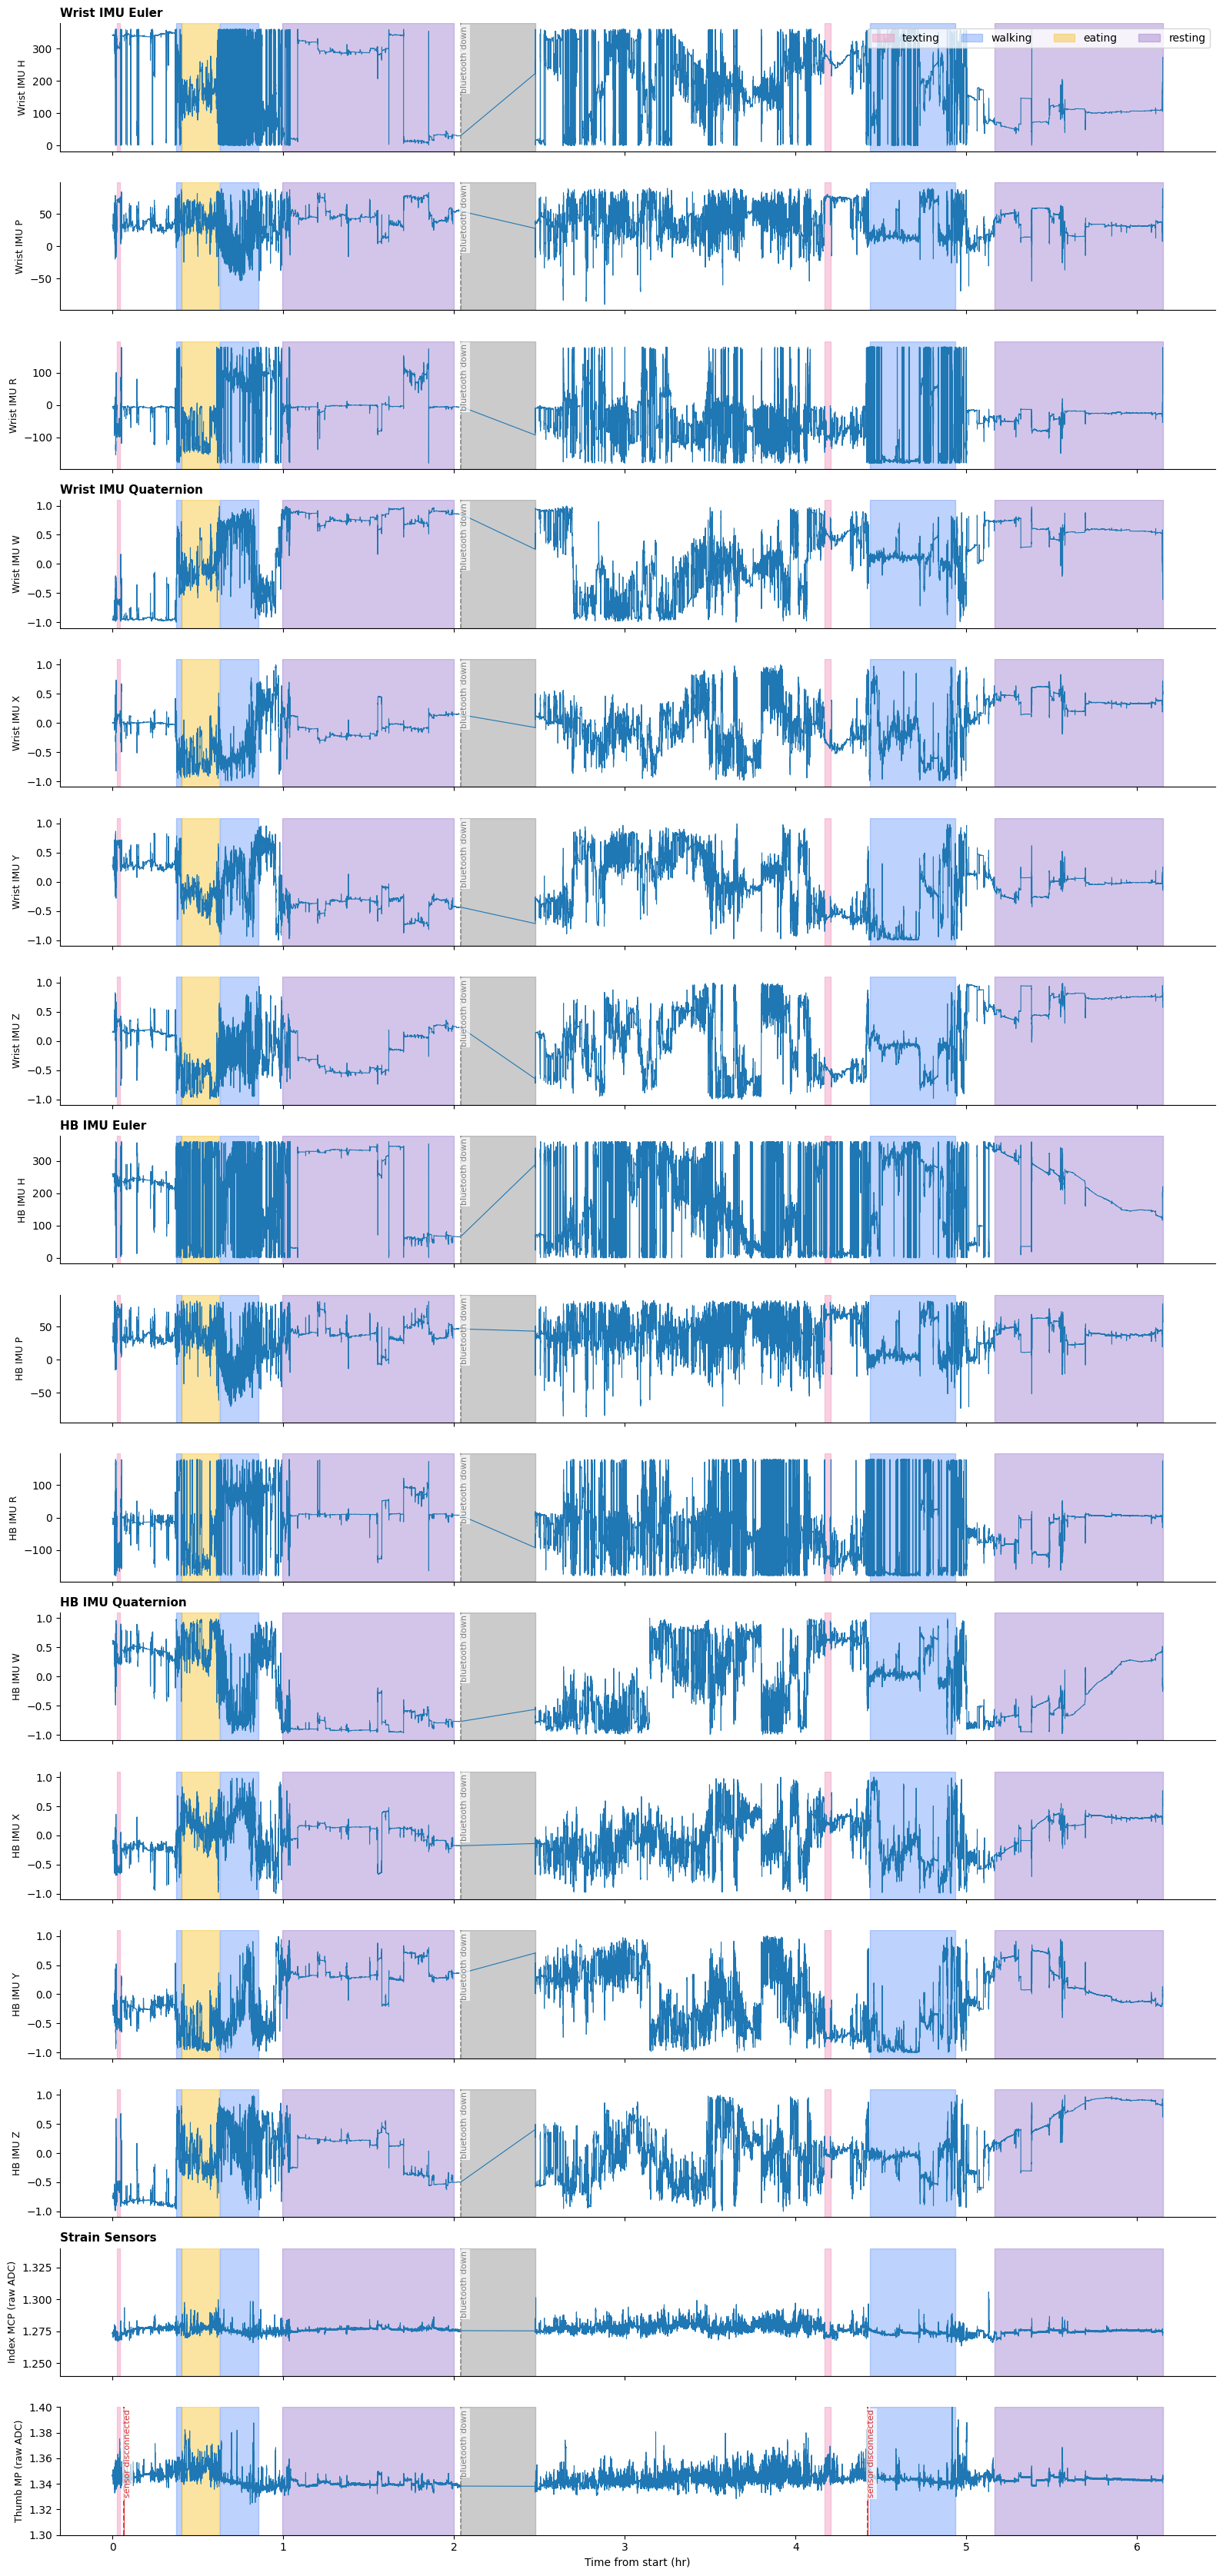

In [60]:
# combo plot
plot_all_signals_one_figure(
    df_plot,
    plot_groups,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map,
    xcol="elapsed_hr",
)

In [61]:
# wrist flex/ext from IMU quats

# compute all Q_rel - bend, pitch, azimuth (default from structured on-hand)
from long_term_wear_plotting import add_wrist_flex_ext_from_imus

df_plot = add_wrist_flex_ext_from_imus(
    df_plot,
    fe_source_col="imu_azimuth_deg",  # placeholderrrrr: UPDATE in config cell
    out_col="wrist_flex_ext_deg",
    zero_baseline=False,              # keep raw for inspection
    sign=1.0,
)

# Add display names for the three intermediate cols
display_name_map["imu_bend_deg"]    = "IMU bend (°)"
display_name_map["imu_pitch_deg"]   = "IMU pitch (°)"
display_name_map["imu_azimuth_deg"] = "IMU azimuth (°)"
display_name_map["wrist_flex_ext_deg"] = "Wrist Flex/Ext (°)"
group_title_map["IMU angles"] = "IMU relative angles (bend / pitch / azimuth)"
group_title_map["Wrist FE"]   = "Wrist flexion / extension"

print("Intermediate columns added:", [c for c in df_plot.columns
      if c in ('imu_bend_deg','imu_pitch_deg','imu_azimuth_deg','wrist_flex_ext_deg')])
df_plot[['imu_bend_deg','imu_pitch_deg','imu_azimuth_deg']].describe()

Intermediate columns added: ['imu_bend_deg', 'imu_pitch_deg', 'imu_azimuth_deg', 'wrist_flex_ext_deg']


,imu_bend_deg,imu_pitch_deg,imu_azimuth_deg
count,2.972287e+06,2.971495e+06,2.972287e+06
mean,6.390235e+01,5.977328e+01,6.680872e+00
std,4.045160e+01,4.856743e+01,3.100340e+01
min,1.895893e-01,6.463952e-04,-8.981623e+01
25%,3.257415e+01,1.984077e+01,-1.241841e+01
50%,5.275494e+01,4.101671e+01,4.624884e+00
75%,9.599117e+01,9.877825e+01,2.530339e+01
max,1.796087e+02,1.799949e+02,8.918482e+01


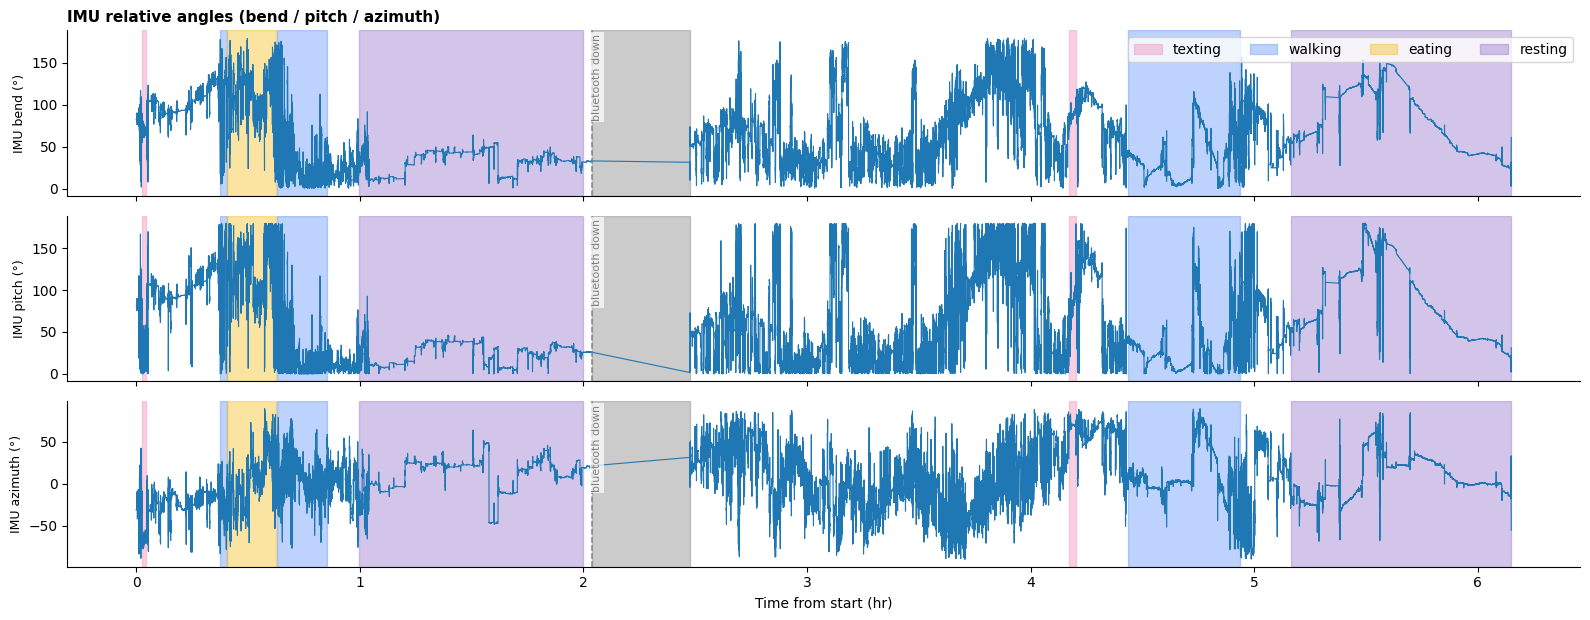

In [62]:
# review all 3 Q_rel
# lots of variation = typing
# no variation = resting
# review polarity too
plot_groups_angles = {
    "IMU angles": ["imu_bend_deg", "imu_pitch_deg", "imu_azimuth_deg"],
}

plot_all_signals_one_figure(
    df_plot,
    plot_groups_angles,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    xcol="elapsed_hr",
)

FE source: imu_azimuth_deg, sign=1.0, zero_baseline=True (median over 1.0s)
count    2.972287e+06
mean     3.788377e+01
std      3.100340e+01
min     -5.861333e+01
25%      1.878449e+01
50%      3.582778e+01
75%      5.650629e+01
max      1.203877e+02
Name: wrist_flex_ext_deg, dtype: float64


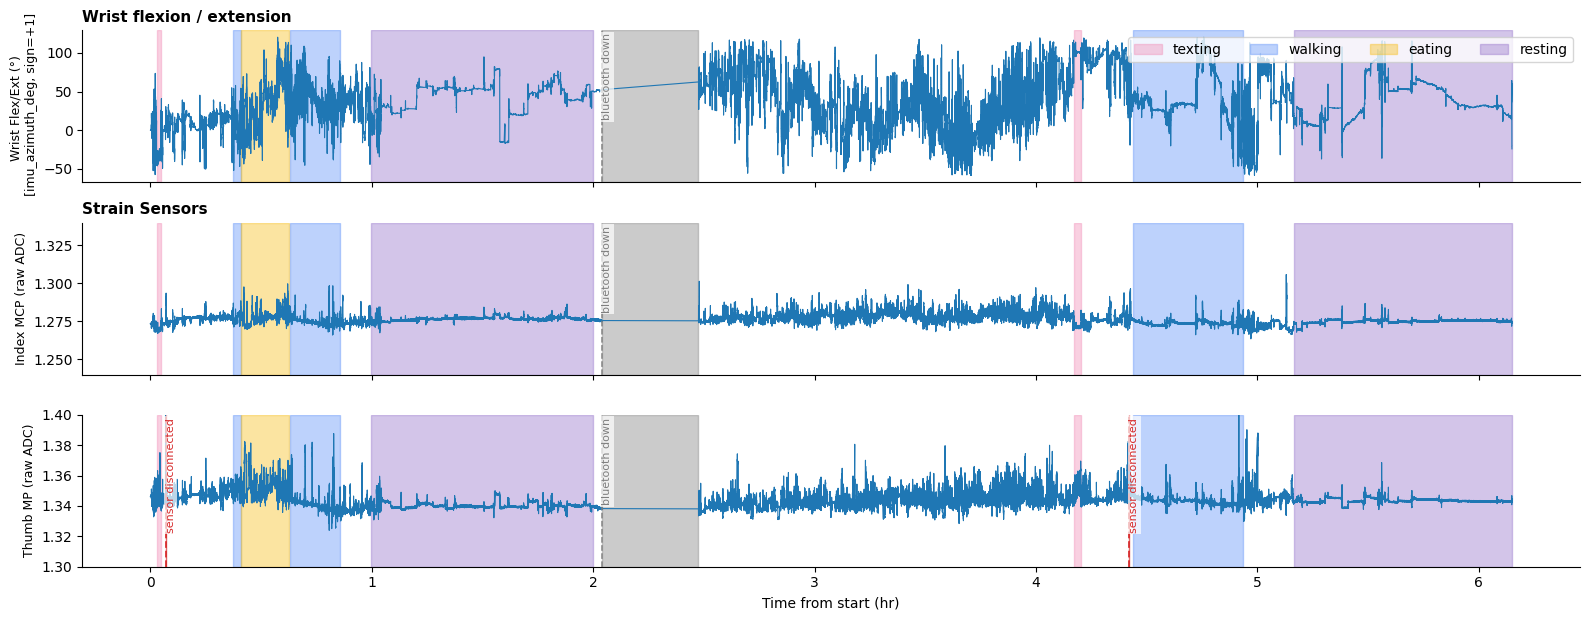

In [63]:
# set FE_SOURCE_COL
FE_SOURCE_COL      = "imu_azimuth_deg"  # "imu_bend_deg" #  "imu_pitch_deg"  
SIGN               = 1.0               # -1.0 to flip so extension > 0, flexion < 0
ZERO_BASELINE      = True
BASELINE_WINDOW_SEC = 1.0              # seconds of leading data used for baseline mean
BASELINE_STAT      = "median"          # "median" or "mean"
FE_YLIM            = (-60, 60)         # y-axis limits for final plot; adjust to data
# ────────────────────────────────────────────────────────────────────────
print(f"FE source: {FE_SOURCE_COL}, sign={SIGN}, "
      f"zero_baseline={ZERO_BASELINE} ({BASELINE_STAT} over {BASELINE_WINDOW_SEC}s)")

df_plot = add_wrist_flex_ext_from_imus(
    df_plot,
    fe_source_col=FE_SOURCE_COL,
    out_col="wrist_flex_ext_deg",
    sign=SIGN,
    zero_baseline=ZERO_BASELINE,
    baseline_window_sec=BASELINE_WINDOW_SEC,
    baseline_stat=BASELINE_STAT,
    #plane_normal_axis='y' # or 'y' if default looks wrong 
)

display_name_map["wrist_flex_ext_deg"] = (
    f"Wrist Flex/Ext (°) \n [{FE_SOURCE_COL}, sign={SIGN:+.0f}]"
)

print(df_plot["wrist_flex_ext_deg"].describe())

# get real wrist_flex_ext_deg + final plot
plot_groups_fe = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "ADC":      ["ADC_ch0", "ADC_ch1"],
}
plot_groups_fe = {
    k: [c for c in v if c in df_plot.columns]
    for k, v in plot_groups_fe.items()
    if any(c in df_plot.columns for c in v)
}

adc_ylim_map_fe = {
    **adc_ylim_map,
    #"wrist_flex_ext_deg": FE_YLIM,
}

plot_all_signals_one_figure(
    df_plot,
    plot_groups_fe,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map_fe,
    xcol="elapsed_hr",
)